##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** A

**Student names & numbers:**
* [Damian van der Sluis] - [101360]
* [Achraf El Azzouzi] - [101674]
* [Saeed Alhasan] - [102384]

---

## 0. Iteration setup

**Import libraries**

In [2]:
# CODE CELL: import the necessary libraries for this iteration
%pip install pandas numpy seaborn matplotlib scikit-learn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


**Load and merge datasets**

In [3]:
df_it1 = pd.read_csv("iteratie1_clean.csv")
df_it2 = pd.read_csv("ship_inspections_iter2.csv")

df = pd.merge(df_it1, df_it2, on="Ship_ID", how="left")

In [4]:
df

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,Critical,40.0,Ion Drive,Shuttle
1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,Pristine,120.0,Solar Sail,Shuttle
2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,Critical,40.0,Ion Drive,Shuttle
3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,Pristine,40.0,Graviton Beam,Shuttle
4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,Critical,40.0,Hyperdrive,Shuttle
...,...,...,...,...,...,...,...,...,...
368309,7314422916,12997,7516.0,Independent Shipwrights,Onderon Wilds,Pristine,120.0,Ion Drive,Shuttle
368310,7310477656,19965,7508.0,General Mining Corp,Wyl Sector,Critical,80.0,Ion Drive,Hauler
368311,7302695121,45990,7518.0,Independent Shipwrights,Indoumodo Sector,Pristine,80.0,NaN,Corvette
368312,7306742082,2000,7494.0,Corellian Engineering,Kashyyyk Homeworld,Critical,240.0,Hyperdrive,Freighter


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

### **Situation description**

*Describe the problem surrounding the safety inspections. Why is the current process (human estimation/gut feeling) a risk?*

De ruwe data voor deze iteratie komt uit meerdere, losse bestanden uit iteratie 1 en 2. Daardoor is de informatie in eerste instantie gefragmenteerd: relevante kenmerken van hetzelfde schip staan niet in één uniforme tabel.
Daarnaast bevat de data kwaliteitsproblemen zoals missende waarden (onder andere in `Propulsion_Type`, `Reactor_Power` en `Model_Cycle`), dubbele records en inconsistente benamingen bij fabrikanten.

Voor de business is dit een probleem omdat inspectiebeslissingen dan worden gebaseerd op onvolledige of tegenstrijdige informatie. Een extra risico is het ontbreken van een eenduidige, gestandaardiseerde rating voor `Hull_Integrity`. Als inspecteurs vooral op ervaring of “gut feeling” werken, ontstaan verschillen tussen personen en teams. Dat leidt tot inconsistente uitkomsten: een schip kan door de ene inspecteur als veilig en door de andere als risicovol worden beoordeeld. Voor de organisatie betekent dit hogere aansprakelijkheids- en reputatierisico’s.

### **Business objective(s)**

*Justify why a standardized, rule-based expert system is needed.*

Het businessdoel in iteratie 2 is om het inspectieproces van Nebula Brokerage te standaardiseren met een uitlegbaar, rule-based systeem dat de `Hull_Integrity` van schepen consistent classificeert als `Critical`, `Operational` of `Pristine`.
Hiermee wil de organisatie de afhankelijkheid van subjectieve “gut feeling” elimineren, inspectiebeslissingen tussen inspecteurs uniform maken en vooral veiligheidsrisico’s door foutieve beoordelingen van kritieke schepen verminderen.

### **Data mining goal(s)**

*Explain what type of modeling task this is and why.*

Dit is een supervised classificatieprobleem: we voorspellen de categorische doelvariabele `Hull_Integrity` met klassen zoals `Critical`, `Operational` en `Pristine`.
Het is classificatie en geen regressie, omdat de output uit discrete labels bestaat en niet uit numerieke waardes.

Voor iteratie 2 kiezen we bewust een handmatig rule-based model (if/elif/else), zodat de logica transparant en controleerbaar blijft en domeinkennis direct kan worden vertaald naar beslisregels.

### **Success criteria**

*Determine success criteria for this iteration*

Succes wordt bepaald op twee niveaus: datasetkwaliteit en modelprestatie.

Dataset-criteria

Gegevens uit iteratie 1 en 2 zijn correct samengevoegd op Ship_ID.
Kritieke velden voor modellering (`Hull_Integrity`, `Reactor_Power`, `Propulsion_Type`) zijn bruikbaar gemaakt via verantwoorde cleaning/imputatie.
Duplicaten en inconsistenties in categorische labels zijn aantoonbaar aangepakt.
De voorbereide dataset is reproduceerbaar en exporteerbaar voor de volgende iteratie.  

Model-criteria

Het rule-based model geeft voor elke observatie met bekende input een voorspelling.
De prestatie wordt geëvalueerd met ten minste accuracy, confusion matrix en class-level metrics (precision/recall).
Veiligheidsfocus: de recall voor Critical moet voldoende hoog zijn. De regels zijn inhoudelijk te verklaren vanuit de data-analyse.

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

In deze sectie analyseren we welke variabelen bruikbaar zijn om `Hull_Integrity` later met handmatige classificatie regels te voorspellen.
We focussen op:
- Samenvattende statistieken
- Datakwaliteit (missende waarden + outliers)
- Patronen tussen `Reactor_Power`, `Propulsion_Type`, `Ship_Class` en `Hull_Integrity`

In [5]:
print("Dataset shape:", df.shape)
print("Kolommen:", list(df.columns))

info_df = pd.DataFrame({
    "Column": df.columns,
    "Non-Null Count": df.notnull().sum().values,
    "Missing": df.isnull().sum().values,
    "Dtype": df.dtypes.values
})
info_df["Missing_%"] = (info_df["Missing"] / len(df) * 100).round(2)
info_df = info_df.sort_values("Missing", ascending=False)

display(info_df)

Dataset shape: (368314, 9)
Kolommen: ['Ship_ID', 'Galactic_Credits', 'Model_Cycle', 'Ship_Manufacturer', 'Sector', 'Hull_Integrity', 'Reactor_Power', 'Propulsion_Type', 'Ship_Class']


,Column,Non-Null Count,Missing,Dtype,Missing_%
7,Propulsion_Type,311704,56610,str,15.37
6,Reactor_Power,338876,29438,float64,7.99
0,Ship_ID,368314,0,int64,0.00
1,Galactic_Credits,368314,0,int64,0.00
2,Model_Cycle,368314,0,float64,0.00
4,Sector,368314,0,str,0.00
3,Ship_Manufacturer,368314,0,str,0.00
5,Hull_Integrity,368314,0,str,0.00
8,Ship_Class,368314,0,str,0.00


De output toont dat de dataset 368.314 rijen en 9 kolommen bevat.  
De belangrijkste datakwaliteitsissues zitten in:
- `Propulsion_Type` mist ongeveer 15,4% waarden.
- `Reactor_Power` mist ongeveer 8% waarden.
- `Model_Cycle` heeft in deze iteratie geen missende waarden meer (0,00%).

In [6]:
display(df.describe(include=[np.number]).T)

,count,mean,std,min,25%,50%,75%,max
Ship_ID,368314.0,7.311484e+09,4.381194e+06,7.301583e+09,7.308103e+09,7.312604e+09,7.315244e+09,7.317101e+09
Galactic_Credits,368314.0,1.945424e+04,1.554266e+04,5.010000e+02,7.950000e+03,1.599000e+04,2.799000e+04,7.777770e+05
Model_Cycle,368314.0,7.511299e+03,8.991369e+00,7.400000e+03,7.508000e+03,7.513000e+03,7.517000e+03,7.522000e+03
Reactor_Power,338876.0,7.159256e+01,4.464415e+01,3.000000e+01,4.000000e+01,6.000000e+01,8.000000e+01,3.600000e+02


De numerieke samenvatting laat de spreiding van onder andere `Galactic_Credits`, `Model_Cycle` en `Reactor_Power` zien.  
Voor deze iteratie is vooral `Reactor_Power` belangrijk: de spreiding en extreme waarden suggereren dat deze variabele een sterke kandidaat is voor beslisregels in het handmatige classificatiemodel.

In [7]:
display(df.describe(include=["object"]).T)

C:\Users\damia\AppData\Local\Temp\ipykernel_26232\1308661061.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["object"]).T)


,count,unique,top,freq
Ship_Manufacturer,368314,28,Independent Shipwrights,94322
Sector,368314,51,Calodan Expanse,42091
Hull_Integrity,368314,3,Operational,141273
Propulsion_Type,311704,8,Ion Drive,177373
Ship_Class,368314,8,Shuttle,125707


De categorische output bevestigt dat `Hull_Integrity` de doelvariabele is met drie klassen (`Critical`, `Operational`, `Pristine`).  
Daarnaast tonen `Propulsion_Type` en `Ship_Class` meerdere categorieën die inhoudelijk bruikbaar zijn om klassen van elkaar te onderscheiden.

In [8]:
print("Verdeling Hull_Integrity in aantallen:")
print(df["Hull_Integrity"].value_counts(dropna=False))

Verdeling Hull_Integrity in aantallen:
Hull_Integrity
Operational    141273
Critical       118487
Pristine       108554
Name: count, dtype: int64


De aantallen per `Hull_Integrity`-klasse laten zien hoe de data over de drie klassen verdeeld is.  
Deze verdeling is belangrijk voor de evaluatie: als een klasse duidelijk een kleiner aantal bevat, moet later extra aandacht gaan naar de recall van die klasse (niet alleen totale accuracy).

In [9]:
print("Verdeling Hull_Integrity in percentages:")
print((df["Hull_Integrity"].value_counts(normalize=True) * 100).round(2))

Verdeling Hull_Integrity in percentages:
Hull_Integrity
Operational    38.36
Critical       32.17
Pristine       29.47
Name: proportion, dtype: float64


Hier nogmaals de verdeling maar dan in percentages.

**Visualizations and patterns**

*Discover patterns in the data that will help you determine the inspection rules. Create visualizations that show the relationship between variables like Reactor_Power, Propulsion_Type, Ship_Class on one side, and the target variable Hull_Integrity on the other. Describe any hard rules you discover (e.g., relationships with dangerous reactors or advanced tech).*

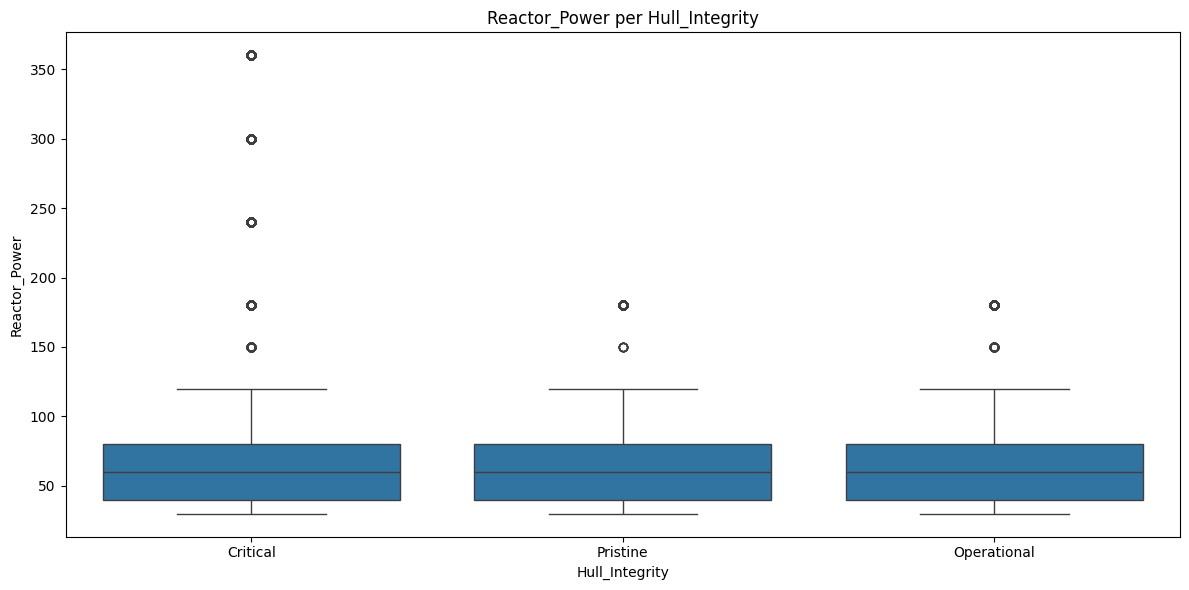

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Hull_Integrity", y="Reactor_Power")
plt.title("Reactor_Power per Hull_Integrity")
plt.tight_layout()
plt.show()

De boxplot toont duidelijke overlap tussen de drie klassen, maar ook zichtbare verschillen in uitschieters.
`Critical` bevat duidelijk meer/extremere hoge uitschieters dan de andere klassen.
Dit wijst erop dat hoge `Reactor_Power` waarden een risicosignaal kunnen zijn, maar dat `Reactor_Power` alleen waarschijnlijk niet voldoende is om alle klassen perfect te scheiden.

In [11]:
rp_stats = df.groupby("Hull_Integrity")["Reactor_Power"].agg(["count", "mean", "median"]).round(2)
display(rp_stats)

,count,mean,median
Hull_Integrity,,,
Critical,109089,80.97,60.0
Operational,129959,62.85,60.0
Pristine,99828,72.73,60.0


De tabel bevestigt dat hoewel de mediaan overal gelijk is (60.0), het gemiddelde sterk verschilt. Vooral bij Critical ligt dit gemiddelde veel hoger, wat duidt op een grotere spreiding naar boven toe. Door eerst te splitsen op Reactor_Power en daarna te verfijnen met deze klassen, vangen we die verschillen in verdeling effectief op in de regels voor classificatie.

In [12]:
rp = df["Reactor_Power"].dropna()

range_quantiles = pd.DataFrame({
    "Metric": ["Minimum", "Q1 (25%)", "Mediaan (50%)", "Q3 (75%)", "Maximum"],
    "Waarde": [
        rp.min(),
        rp.quantile(0.25),
        rp.median(),
        rp.quantile(0.75),
        rp.max()
    ]
})

range_quantiles["Waarde"] = range_quantiles["Waarde"].round(2)
display(range_quantiles)

,Metric,Waarde
0,Minimum,30.0
1,Q1 (25%),40.0
2,Mediaan (50%),60.0
3,Q3 (75%),80.0
4,Maximum,360.0


In deze tabel tonen we de spreiding van Reactor_Power met de minimum- en maximumwaarde en de belangrijkste quantiles (Q1, mediaan, Q3).  
Hiermee maken we expliciet hoe breed de verdeling is en of de hoogste waarden sterk afwijken van het grootste deel van de data.

Deze output gebruiken we als onderbouwing voor de outlier-analyse (IQR) in de volgende cel.

In [13]:
rp = df["Reactor_Power"].dropna()
q1 = rp.quantile(0.25)
q3 = rp.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df["Reactor_Power"] < lower) | (df["Reactor_Power"] > upper)]

print("IQR lower bound:", round(lower, 2))
print("IQR upper bound:", round(upper, 2))
print("Aantal mogelijke outliers:", len(outliers))
print("Percentage mogelijke outliers:", round(len(outliers) / len(df) * 100, 2), "%")

IQR lower bound: -20.0
IQR upper bound: 140.0
Aantal mogelijke outliers: 20580
Percentage mogelijke outliers: 5.59 %


De IQR-analyse geeft een onder- en bovengrens voor normale waarden van `Reactor_Power` en toont hoeveel observaties daarbuiten vallen.  
Deze observaties labelen we als mogelijke outliers, maar we verwijderen ze in deze fase niet automatisch.

In [14]:
prop_tab = pd.crosstab(df["Propulsion_Type"], df["Hull_Integrity"], normalize="index")
prop_tab_pct = (prop_tab * 100).round(1).astype(str) + '%'
display(prop_tab_pct)

Hull_Integrity,Critical,Operational,Pristine
Propulsion_Type,,,
Antimatter,1.7%,0.9%,97.3%
Graviton Beam,2.3%,10.4%,87.3%
Hyperdrive,36.8%,38.2%,25.0%
Ion Drive,32.9%,40.4%,26.7%
Nuclear Pulse,42.8%,46.8%,10.4%
Plasma Hybrid,8.8%,54.1%,37.1%
Plasma Thruster,40.3%,35.6%,24.1%
Solar Sail,25.9%,37.3%,36.7%


De genormaliseerde tabel laat zien dat de verhouding `Critical/Operational/Pristine` sterk verschilt per `Propulsion_Type`.  
Voorbeeld uit de grafiek en tabel: sommige propulsion-types hebben een veel groter aandeel `Pristine`, terwijl andere types meer `Critical/Operational` bevatten.  
Dit maakt `Propulsion_Type` een sterke tweede voorwaarde in if-regels voor de classificatie.

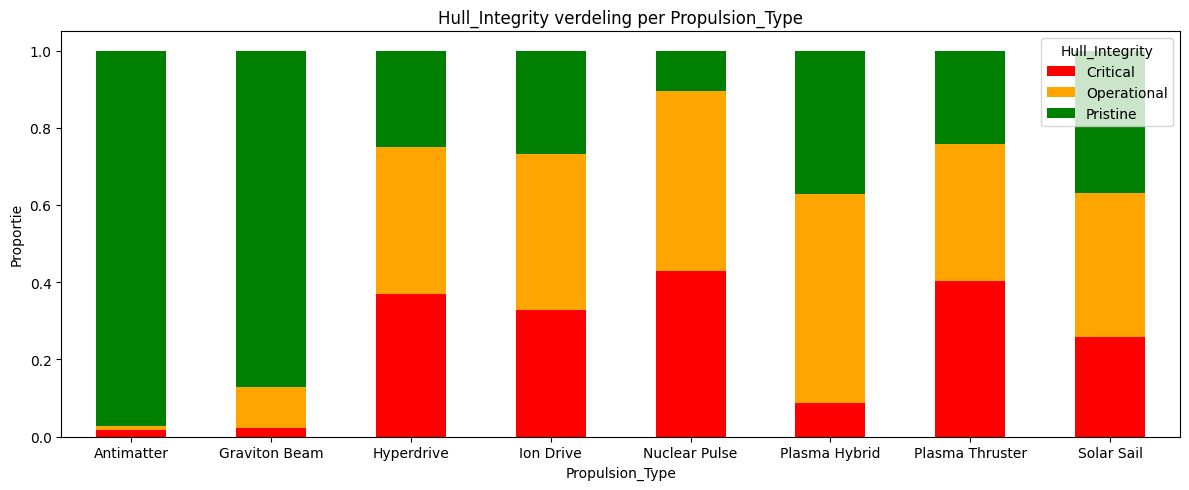

In [15]:
prop_tab.plot(kind="bar", stacked=True, figsize=(12, 6), color=["red", "orange", "green"])
plt.title("Hull_Integrity verdeling per Propulsion_Type")
plt.ylabel("Proportie")
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

De stacked bar chart bevestigt duidelijke patroonverschillen per propulsion-type:
- `Antimatter` en `Graviton Beam` zijn vooral `Pristine`
- `Nuclear Pulse` en `Plasma Thruster` hebben relatief veel `Critical`
- De rest heeft een relatief gelijkere verdeling.

`antimatter` en `Graviton beam` kunnen we dus gebruiken voor de classificatie regels.

In [16]:
class_tab = pd.crosstab(df["Ship_Class"], df["Hull_Integrity"], normalize="index")
class_tab_pct = (class_tab * 100).round(1).astype(str) + '%'
display(class_tab_pct)

Hull_Integrity,Critical,Operational,Pristine
Ship_Class,,,
Corvette,27.1%,42.4%,30.5%
Explorer,29.8%,39.2%,31.0%
Fighter,33.8%,30.6%,35.6%
Freighter,36.7%,34.4%,28.9%
Hauler,26.2%,31.7%,42.1%
Shuttle,36.5%,39.8%,23.7%
Speedster,47.4%,30.2%,22.4%
Troop Transport,30.4%,40.4%,29.2%


De verdeling per Ship_Class is grotendeels vergelijkbaar tussen de drie Hull_Integrity-klassen.
Daarom gebruiken we Ship_Class niet als regel voor de classificatie.

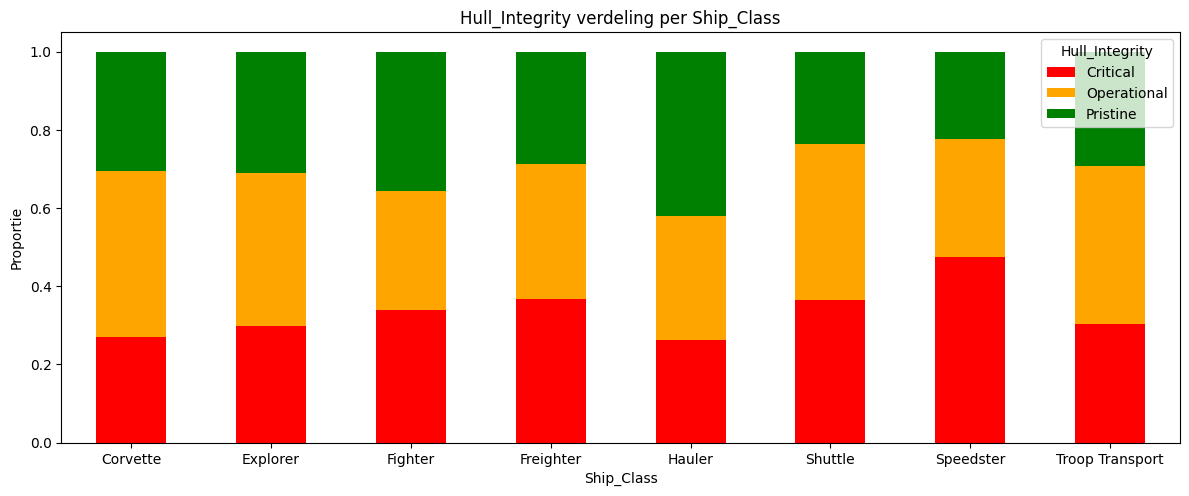

In [17]:
class_tab.plot(kind="bar", stacked=True, figsize=(12, 6), color=["red", "orange", "green"])
plt.title("Hull_Integrity verdeling per Ship_Class")
plt.ylabel("Proportie")
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

De visualisatie bevestigt dat de verdelingen per Ship_Class over het algemeen vrij vergelijkbaar zijn.  
Er zijn kleine verschillen (zoals een hoger aandeel Critical bij Speedster en een hoger aandeel Pristine bij Hauler), maar de klassen worden niet sterk van elkaar gescheiden op basis van Ship_Class alleen.

Conclusie:
Ship_Class gebruiken we niet als classificatieregel.

**Ship_Manufacturer vs Propulsion_Type**

Om missende waarden in Propulsion_Type onderbouwd in te vullen, onderzoeken we eerst of bepaalde manufacturers vooral met specifieke propulsion-types voorkomen.  
Als die relatie sterk is, is imputatie per manufacturer logischer dan 1 globale invulwaarde.

In [18]:
man_prop_pct = pd.crosstab(df["Ship_Manufacturer"], df["Propulsion_Type"], normalize="index", dropna=False) * 100

manufacturers = df["Ship_Manufacturer"].value_counts().index

display(man_prop_pct.loc[manufacturers].round(1).astype(str) + "%")

Propulsion_Type,Antimatter,Graviton Beam,Hyperdrive,Ion Drive,Nuclear Pulse,Plasma Hybrid,Plasma Thruster,Solar Sail,NaN
Ship_Manufacturer,,,,,,,,,
Independent Shipwrights,0.7%,0.0%,0.0%,73.5%,1.3%,1.0%,0.0%,7.9%,15.6%
Galactic Motors,0.1%,0.0%,0.0%,66.2%,11.8%,0.9%,0.0%,5.6%,15.5%
Corellian Engineering,0.0%,0.0%,84.8%,0.0%,0.0%,0.0%,0.0%,0.0%,15.2%
Kuat Drive Yards,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,84.8%,0.0%,15.2%
Hondo Systems,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,84.8%,15.2%
Jumpship Corp,0.0%,0.0%,0.0%,79.4%,0.8%,0.3%,0.0%,4.5%,15.0%
Republic Aerospace,0.0%,0.0%,0.0%,51.7%,28.0%,0.1%,0.0%,4.8%,15.4%
General Mining Corp,0.0%,0.0%,0.0%,65.3%,11.8%,0.1%,0.0%,6.7%,16.1%
Nebula Industries,0.0%,85.1%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,14.9%


De percentage-tabel laat zien dat de relatie tussen manufacturer en propulsion duidelijk niet willekeurig is.  
Voor meerdere manufacturers is er één dominante propulsion-vorm met een hoog aandeel (boven 70%), en bij enkele manufacturers is die dominantie volledig.

Dit is belangrijk voor de missende waarden in `Propulsion_Type`:
imputatie op basis van `Ship_Manufacturer` is inhoudelijk sterker dan één globale invulwaarde, omdat manufacturers duidelijk verschillende propulsion-profielen hebben.

<Figure size 2000x1000 with 0 Axes>

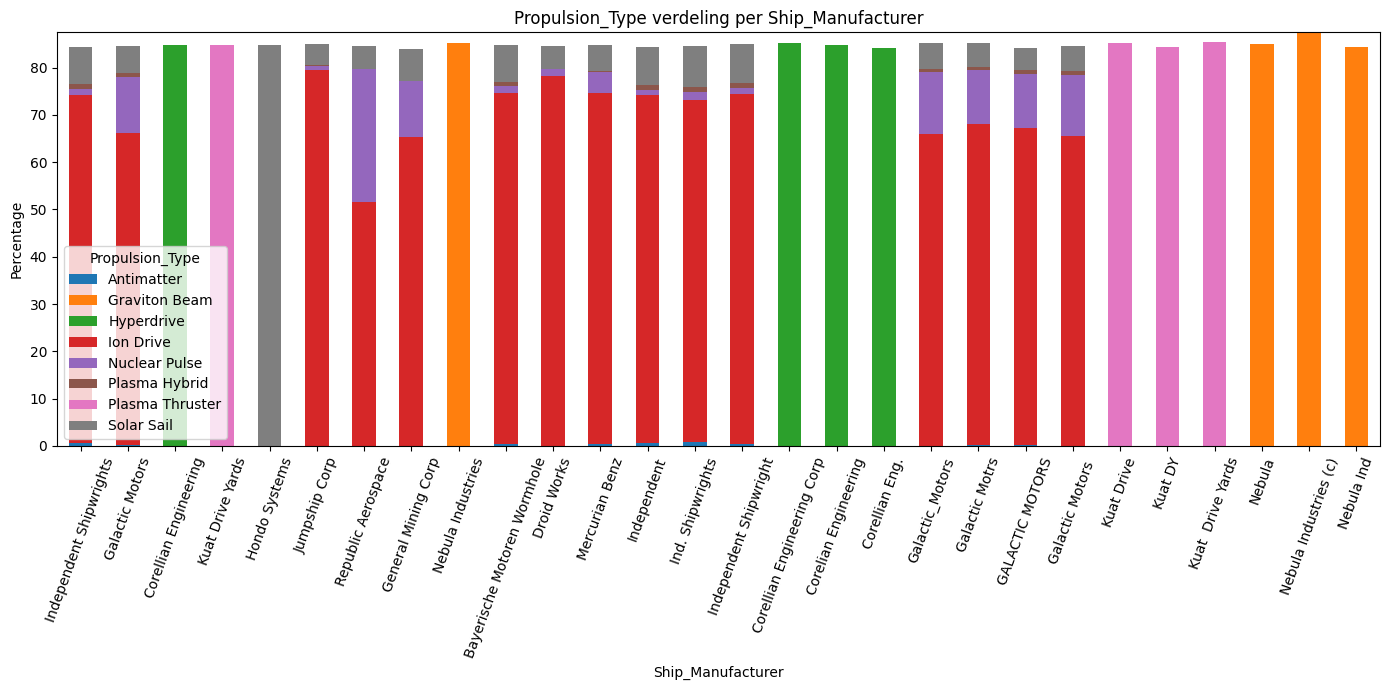

In [19]:
plt.figure(figsize=(20, 10))
(
    man_prop_pct.loc[manufacturers]
    .drop(columns=[c for c in man_prop_pct.columns if str(c) == "nan"], errors="ignore")
    .plot(kind="bar", stacked=True, figsize=(14, 7))
)
plt.title("Propulsion_Type verdeling per Ship_Manufacturer")
plt.ylabel("Percentage")
plt.xlabel("Ship_Manufacturer")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

De grafiek bevestigt het patroon uit de tabel: veel manufacturers hebben één kleur die het grootste deel van de staaf inneemt, wat wijst op een dominante propulsion keuze per manufacturer.

Conclusie:
1. Er is een sterke samenhang tussen Ship_Manufacturer en Propulsion_Type. Hierdoor kunnen we bij de missende waardes het `Propuslion_Type` betrouwbaar afleiden vanuit `Ship_Manufacturer`.
2. Voor dat we dat kunnen doen, moeten we wel eerst de namen van `Ship_manufacturer` standaardiseren.

In [20]:
# Galactic_Credits: beschrijvende statistiek + percentielen

gc_describe = pd.DataFrame({
    "Metric": ["Minimum", "Q1 (25%)", "Mediaan (50%)", "Q3 (75%)", "P90 (90%)", "Maximum", "Gemiddelde", "Standard deviation"],
    "Waarde": [
        df["Galactic_Credits"].min(),
        df["Galactic_Credits"].quantile(0.25),
        df["Galactic_Credits"].median(),
        df["Galactic_Credits"].quantile(0.75),
        df["Galactic_Credits"].quantile(0.90),
        df["Galactic_Credits"].max(),
        df["Galactic_Credits"].mean(),
        df["Galactic_Credits"].std()
    ]
})
gc_describe["Waarde"] = gc_describe["Waarde"].round(2)
display(gc_describe)

,Metric,Waarde
0,Minimum,501.00
1,Q1 (25%),7950.00
2,Mediaan (50%),15990.00
3,Q3 (75%),27990.00
4,P90 (90%),38590.00
5,Maximum,777777.00
6,Gemiddelde,19454.24
7,Standard deviation,15542.66


Deze tabel geeft een samenvatting van de verdeling van Galactic_Credits met centrum- en spreidingsmaten (minimum, kwartielen, mediaan, maximum, gemiddelde en standaarddeviatie).
De combinatie van een hoog maximum en een duidelijk verschil met de kwartielen wijst op een scheve verdeling met extreme waarden (rechtsscheef).
Daarom is het nuttig om naast deze tabel ook robuustere visualisaties te gebruiken waarin uitschieters apart bekeken of tijdelijk gefilterd worden.

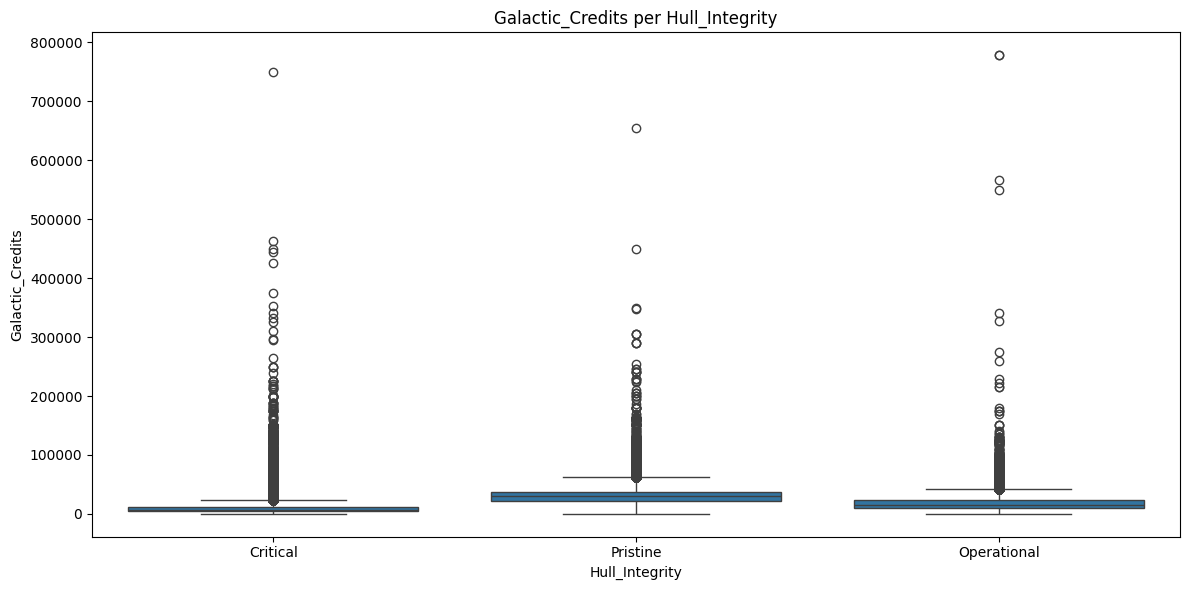

In [21]:
# Galactic_Credits vs Hull_Integrity (boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Hull_Integrity", y="Galactic_Credits")
plt.title("Galactic_Credits per Hull_Integrity")
plt.tight_layout()
plt.show()

De boxplot met uitschieters laat de volledige spreiding per Hull_Integrity-klasse zien, inclusief uitschieters.
Hiermee zien we dat de klassen in centrale waarden gedeeltelijk overlappen, maar dat vooral de bovenste staarten en uitschieters verschillen.
Dit ondersteunt het idee dat Galactic_Credits informatief is, maar niet als enige variabele voldoende voor harde classificatieregels.

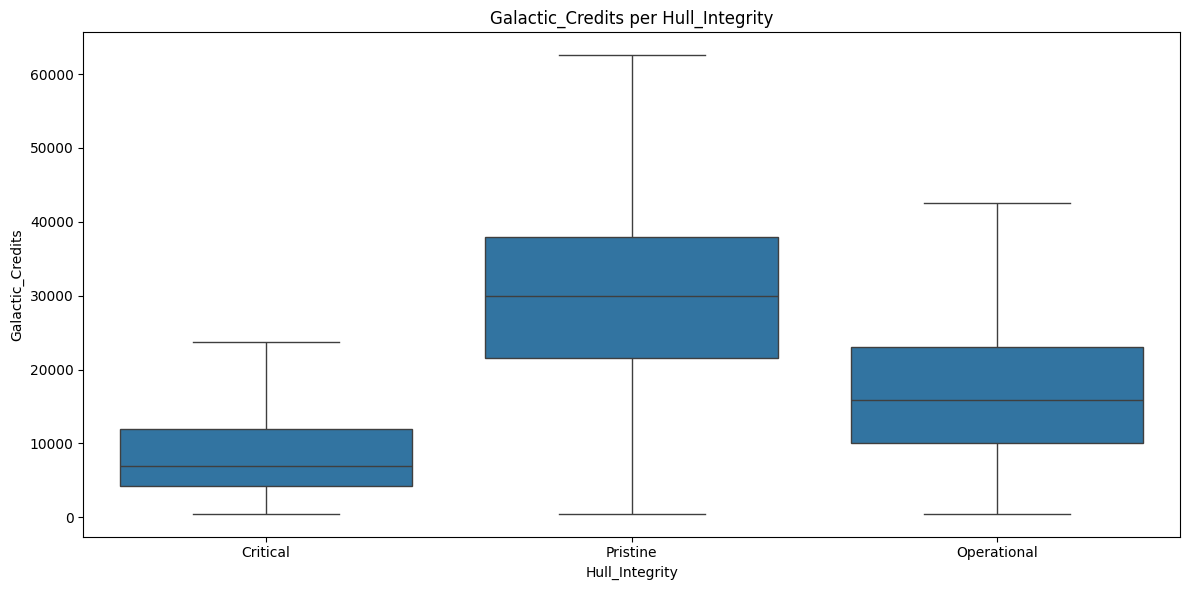

In [22]:
# Zelfde maar dan zonder uitschieters
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Hull_Integrity", y="Galactic_Credits", showfliers=False)
plt.title("Galactic_Credits per Hull_Integrity")
plt.tight_layout()
plt.show()

Door uitschieters te verbergen wordt de vergelijking van de mediaan en interkwartielafstand tussen de klassen veel duidelijker. De centrale delen van de klassen blijven nog steeds deels overlappend, wat aangeeft dat het onderscheid niet volledig scherp is op basis van Galactic_Credits alleen.
Deze weergave is vooral nuttig om stabiele patronen te zien zonder dat extreme waarden het beeld domineren.

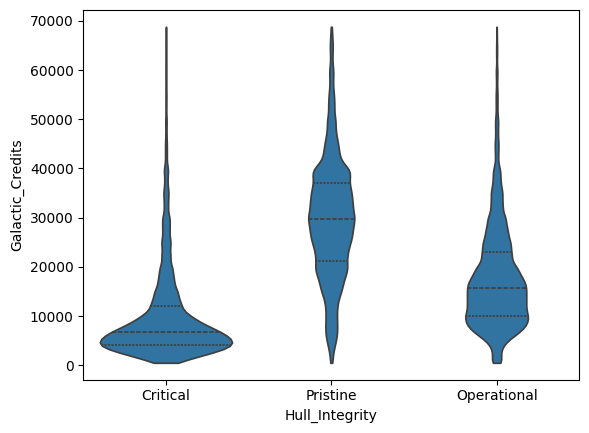

In [23]:
q99 = df["Galactic_Credits"].quantile(0.99)
df_plot = df[df["Galactic_Credits"] <= q99].copy()
sns.violinplot(
    data=df_plot, x="Hull_Integrity", y="Galactic_Credits", inner="quartile", cut=0
);

Na filtering tot en met het 99e percentiel zien we dat Pristine gemiddeld duidelijk hogere Galactic_Credits heeft dan `Operational` en `Critical`. `Operational` zit vooral in het middengebied, terwijl `Critical` vooral bij lagere credits voorkomt. Er is wel nog overlap tussen de klassen, dus Galactic_Credits alleen is geen harde beslisregel, maar wel een bruikbare ondersteunende variabele.

In [24]:
credit_bin_width = 10000
credits_p99 = df["Galactic_Credits"].quantile(0.99)
credits_upper_limit = int(credits_p99)

credit_bin_edges = list(
    range(
        0,
        (credits_upper_limit // credit_bin_width) * credit_bin_width + credit_bin_width,
        credit_bin_width,
    )
)
if credit_bin_edges[-1] < credits_upper_limit:
    credit_bin_edges.append(credits_upper_limit)

credit_bin_labels = [
    f"{credit_bin_edges[i]}-{credit_bin_edges[i + 1]}"
    for i in range(len(credit_bin_edges) - 1)
]

filtered_credit_hull_df = df.loc[
    (df["Hull_Integrity"].notna()) & (df["Galactic_Credits"] <= credits_p99),
    ["Galactic_Credits", "Hull_Integrity"],
].copy()

filtered_credit_hull_df["Galactic_Credits_Bin"] = pd.cut(
    filtered_credit_hull_df["Galactic_Credits"],
    bins=credit_bin_edges,
    labels=credit_bin_labels,
    include_lowest=True,
    right=True,
)

hull_integrity_pct_by_credit_bin = (
    pd.crosstab(
        filtered_credit_hull_df["Galactic_Credits_Bin"],
        filtered_credit_hull_df["Hull_Integrity"],
        normalize="index",
    )
    .mul(100)
    .round(2)
)

display(hull_integrity_pct_by_credit_bin)

Hull_Integrity,Critical,Operational,Pristine
Galactic_Credits_Bin,,,
0-10000,66.28,28.27,5.45
10000-20000,20.91,61.41,17.67
20000-30000,10.97,41.37,47.66
30000-40000,7.76,22.66,69.59
40000-50000,8.47,21.61,69.92
50000-60000,9.59,25.24,65.17
60000-68788,9.51,22.78,67.71


De tabel met credit-intervallen laat zien dat lagere Galactic_Credits-klassen relatief meer `Critical` bevatten, terwijl in hogere klassen het aandeel `Pristine` toeneemt. `Operational` blijft in de meeste klassen aanwezig als tussencategorie, waardoor de klassen niet volledig van elkaar gescheiden zijn. Dit betekent dat `Galactic_Credits` nuttig kan zijn voor de classificatieregels, maar in combinatie met andere variabelen gebruikt moet worden voor sterke regels.

**Data insights**  
*Samenvatting*  
Uit de analyse blijkt dat `Reactor_Power` en `Propulsion_Type` de meest bruikbare variabelen zijn voor classificatie van `Hull_Integrity`, omdat er een duidelijk verband zit tussen de de Hull_Integrity en de Reactor power en het propulsion type. Daarentegen zien we geen sterk verband terug tussen het `Ship_Class` en de Hull_Integrity, daarom gebruiken `Ship_Class` niet voor de classificatieregels.


Belangrijkste inzichten:
- `Reactor_Power` toont klasseverschillen en duidelijke extreme waarden
- `Propulsion_Type` geeft sterke verschillen in klasseverdeling
- `Ship_Class` gebruiken we NIET voor de classificatie.
- Datakwaliteit vraagt aandacht: missende waarden in `Propulsion_Type` en `Reactor_Power`, plus aanwezige outliers.
- Er is een duidelijke samenhang tussen `Ship_Manufacturer` en `Propulsion_Type`: veel manufacturers hebben een dominant `Propulsion-Type`. Daardoor is het invullen van missende `Propulsion_Type` waarden op basis van `Ship_Manufacturer` inhoudelijk beter dan één globale invulwaarde.
- Varianten in `Ship_Manufacturer` zoals verschillende schrijfwijzen van dezelfde fabrikant moeten eerst worden gestandaardiseerd.
- Galactic_Credits is een bruikbare ondersteunende variabele voor de classificatie, maar geen hoofdregel op zichzelf; door overlap tussen klassen werkt deze vooral goed in combinatie met Reactor_Power en Propulsion_Type.

Conclusie:  
In Modeling maken we een handmatige classifier. We gebruiken `Reactor_Power` als belangrijkste regel en `Propulsion_Type` als extra verfijning. `Galactic_Credits` gebruiken we aanvullend als ondersteunende variabele, niet als hoofdregel, omdat deze pas in combinatie met de andere regels voldoende onderscheidend is. `Ship_Class` nemen we niet mee, omdat die minder onderscheid maakt. Missende `Propulsion_Type` vullen we in via `Ship_Manufacturer`, nadat de verschillende schrijfwijzen van manufacturers eerst zijn gestandaardiseerd.

**Data quality**

In [25]:
total_duplicates = df.duplicated().sum()
shipid_duplicates = df.duplicated(subset=["Ship_ID"]).sum()

print("Totaal aantal duplicaten", total_duplicates)
print("Duplicaten op Ship_ID:", shipid_duplicates)

Totaal aantal duplicaten 0
Duplicaten op Ship_ID: 0


In [26]:
cat_cols = ["Ship_Manufacturer"]

for col in cat_cols:
    print(f"\n--- {col} ---")
    print("Unieke waarden:", df[col].nunique(dropna=True))
    
    manufacturer_count = df[col].value_counts(dropna=False)
    print(manufacturer_count)


--- Ship_Manufacturer ---
Unieke waarden: 28
Ship_Manufacturer
Independent Shipwrights        94322
Galactic Motors                57397
Corellian Engineering          44544
Kuat Drive Yards               27792
Hondo Systems                  19371
Jumpship Corp                  16783
Republic Aerospace             16168
General Mining Corp            15215
Nebula Industries              15108
Bayerische Motoren Wormhole    13305
Droid Works                    11666
Mercurian Benz                 10071
Independent                     3514
Ind. Shipwrights                3493
Independent Shipwright          3473
Corellian Engineering Corp      1656
Corelian Engineering            1649
Corellian Eng.                  1644
Galactic_Motors                 1635
Galactic Motrs                  1600
GALACTIC MOTORS                 1592
Galactic Motors                 1550
Kuat Drive                      1034
Kuat DY                         1030
Kuat  Drive Yards               1024
Nebula     

Op basis van de outputs zien we het volgende:

- Totaal aantal duplicaten: 0
- Duplicaten op `Ship_ID`: 0

Dit bevestigt dat de samengevoegde dataset op recordniveau en op (`Ship_ID`) geen dubbele observaties bevat. In de Data Preparation-stap is dus geen extra deduplicatie op `Ship_ID` meer nodig.

Typos en inconsistente labels:
Bij `Ship_Manufacturer` zien we duidelijke varianten die inhoudelijk waarschijnlijk hetzelfde betekenen, bijvoorbeeld:
- Independent Shipwrights
- Independent
- Ind. Shipwrights
- Independent Shipwright

Het gaat hier om verschillende schrijfwijzen voor dezelfde groepen, niet om unieke nieuwe klassen. Bij het opschonen van de data standaardiseren we deze verschillende namen tot een uniforme naam.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**

In deze stap maken we de data schoon en lossen we de missende waarden (missing values) op voor de kolommen die we straks in het model gaan gebruiken. We doen dit op de volgende manier:

1. **Kopie van de data:** We maken eerst een kopie (`df.copy()`) genaamd `df_prep`, zodat we altijd terug kunnen grijpen op de onaangetaste originele dataset.
2. **Lege waarden standaardiseren:** Eventuele onzichtbare lege tekstvakjes (`""`) in `Propulsion_Type` veranderen we in daadwerkelijke `pd.NA` (Not a Number) waardes. Bij de `Reactor_Power` dwingen we de hele kolom om numeriek te zijn (`errors="coerce"`), waardoor typfouten automatisch ook in een herkenbare 'missing value' veranderen.
3. **Missende waarden invullen (Imputatie):**
   - **Categorisch (`Propulsion_Type`):** Deze vullen we op met de *modus* (`mode()[0]`), oftewel de aandrijving die over de hele dataset het vaakst voorkomt. Dit is de meest waarschijnlijke veilige gok voor een ontbrekend label.
   - **Numeriek (`Reactor_Power`):** Deze vullen we in met de *mediaan*. Zoals we in hoofdstuk 2 zagen bij de IQR- en boxplot-analyse, bevat `Reactor_Power` flink wat extreme uitschieters (outliers). Zouden we het gemiddelde gebruiken, dan trekken die uitschieters dat getal scheef. De mediaan (exact het middelste getal) is daar immuun voor en is daardoor een stuk accurater.

**Wat betekent de output?**
De laatste regel print een overzicht van hoeveel `NA` (missende) waarden er nu nog over zijn voor die twee kolommen. De output laat bij beide kolommen een `0` zien. Dit is ons keiharde bewijs dat de cleaning succesvol is afgerond: de data is compleet, bevat geen 'gaten' meer en is klaar om te worden geëxporteerd naar de machine learning stap.

In [32]:
df_prep = df.copy()

df_prep["Propulsion_Type"] = df_prep["Propulsion_Type"].replace("", pd.NA)

df_prep["Reactor_Power"] = pd.to_numeric(df_prep["Reactor_Power"], errors="coerce")

df_prep["Propulsion_Type"] = df_prep["Propulsion_Type"].fillna(df_prep["Propulsion_Type"].mode()[0])

df_prep["Reactor_Power"] = df_prep["Reactor_Power"].fillna(df_prep["Reactor_Power"].median())

print(df_prep[["Propulsion_Type", "Reactor_Power"]].isna().sum())

Propulsion_Type    0
Reactor_Power      0
dtype: int64


**Adjusting dataset voor het uiteindelijke model**

Nu de originele ontbrekende waarden gedicht zijn, verkleinen en filteren we de data puur terug op alleen de variabelen (`Ship_Class`, `Propulsion`, etc.) die een daadwerkelijke rol en aandeel gaan moeten spelen in de uiteindelijke uitkomst. 
* Waarom doen we dit? De redenen hiervoor is dat overtollige kolom-ruis en lege eindbestemmingen (`Hull_Integrity`) niet per ongeluk als 'kennis' geregistreerd mogen worden door het model, waardoor alle voorspellingen valselijk vertroebelen.
Daarop printen we tevens exact de vernauwde `Head` én een vormgetal qua hoeveel rijen en modelzuivere kolommen we uiteindelijk ter beschikking hebben ("The shape (de omvang en afmeting).

In [28]:
df_model = df_prep.dropna(subset=["Hull_Integrity"]).copy()
model_cols = ["Ship_ID", "Ship_Class", "Propulsion_Type", "Reactor_Power", "Hull_Integrity"]
df_model = df_model[model_cols]

print(df_model.shape)
df_model.head()

(368314, 5)


,Ship_ID,Ship_Class,Propulsion_Type,Reactor_Power,Hull_Integrity
0,7316160254,Shuttle,Ion Drive,40.0,Critical
1,7316115206,Shuttle,Solar Sail,120.0,Pristine
2,7315865657,Shuttle,Ion Drive,40.0,Critical
3,7314772431,Shuttle,Graviton Beam,40.0,Pristine
4,7311539325,Shuttle,Hyperdrive,40.0,Critical


**Dataset Exporteren**

Voor iteratie 3 hebben we uiteraard exact doordachte, kloppende data ('clean data') nodig die we zonet hier met ons team hebben opgezet en gerepareerd. In deze code-cel, schrijven we dit veilige nieuwe document dan ook weg. Als er op dat moment iets onvoorziens is veranderd waarschuwt het script de gebruiker zelf hierop middels een unieke NameError (Exceptions) die het runnen beëindigt. Dat stelt al het verdere (eventuele vertekende) opvolgende werk perfect veilig en houdt de versies puur.

In [29]:
if "df_prep" not in globals():
    raise NameError("df_prep is niet gevonden. Run eerst de Data Preparation-cel.")

df_prep.to_csv("iteratie2_cleaned.csv", index=False)

---
## 4. Modeling
*Rubric: LO 6.4C (Process) & LO 6.4D (Reflection on Process)*

**Hoe werkt ons model?**

We gebruiken de inzichten uit de data-analyse van hoofdstuk 2 om de veiligheidsstatus (`Hull_Integrity`) in te schatten. Eigenschappen waarvoor geen sterk verband is gevonden (zoals `Ship_Class`) of die we niet hebben geanalyseerd (zoals `Galactic_Credits` of `Model_Cycle`) laten we achterwege, zodat de regels eerlijk en onderbouwd zijn.

Op basis van hoofdstuk 2 hebben we de volgende simpele, handmatige regels opgesteld:

1. **Gevaarlijke reactors (> 90 kracht) = Critical.**  
   Uit de analyse blijkt dat de uitschieters met de hoogste `Reactor_Power` voornamelijk in de conditie 'Critical' vallen. Een te zware reactor vormt een enorm risico, dus deze beoordelen we direct als onveilig.
2. **Moderne aandrijving (Antimatter of Graviton Beam) = Pristine.**  
   De verdelingen toonden aan dat deze moderne types aandrijving voornamelijk voorkomen bij perfect onderhouden schepen (Pristine). We classificeren ze dan ook als zodanig.
3. **Oudere aandrijving (Nuclear Pulse of Plasma Thruster) = Critical.**  
   Voor deze aandrijvingen zagen we in hoofdstuk 2 een in verhouding erg hoog aandeel schepen met kritieke status (Critical). 
4. **De rest = Operational.**  
   Als een schip niet in de bovenstaande specifieke risico- of topcategorieën valt, is de veiligste en meest waarschijnlijke aanname dat het in algemene, operationele staat verkeert.

We hebben deze logica rechttoe rechtaan geprogrammeerd met overzichtelijke `if`- en `elif`-regels op de voorbereide data (`df_model`).

In [30]:
from sklearn.model_selection import train_test_split
target = df_model['Hull_Integrity']
features = df_model[['Propulsion_Type', 'Reactor_Power']] 
feature_train, feature_test, target_train, target_test = train_test_split(
    features, target, test_size=0.25, random_state=42
)

def manual_classification_model(row):
    if row['Reactor_Power'] > 90:
        return 'Critical'
    elif row['Propulsion_Type'] in ['Antimatter', 'Graviton Beam']:
        return 'Pristine'
    elif row['Propulsion_Type'] in ['Nuclear Pulse', 'Plasma Thruster']:
        return 'Critical'
    return 'Operational'

feature_train['Prediction'] = feature_train.apply(manual_classification_model, axis=1)
feature_test['Prediction'] = feature_test.apply(manual_classification_model, axis=1)
df['Hull_Predicted'] = df.apply(manual_classification_model, axis=1)

Met de code hierboven laten we deze logische regels automatisch schip voor schip los op de hele dataset. Elk schip krijgt zo een voorspelde label. In de cel hieronder gaan we controleren hoe goed de aannames zijn.

**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

Accuracy of train set: 0.4235487899795464
Accuracy of test set: 0.4253630035078574

Classification report (Test set):
              precision    recall  f1-score   support

    Critical       0.37      0.28      0.32     29544
 Operational       0.42      0.78      0.55     35403
    Pristine       0.89      0.11      0.20     27132

    accuracy                           0.43     92079
   macro avg       0.56      0.39      0.36     92079
weighted avg       0.54      0.43      0.37     92079



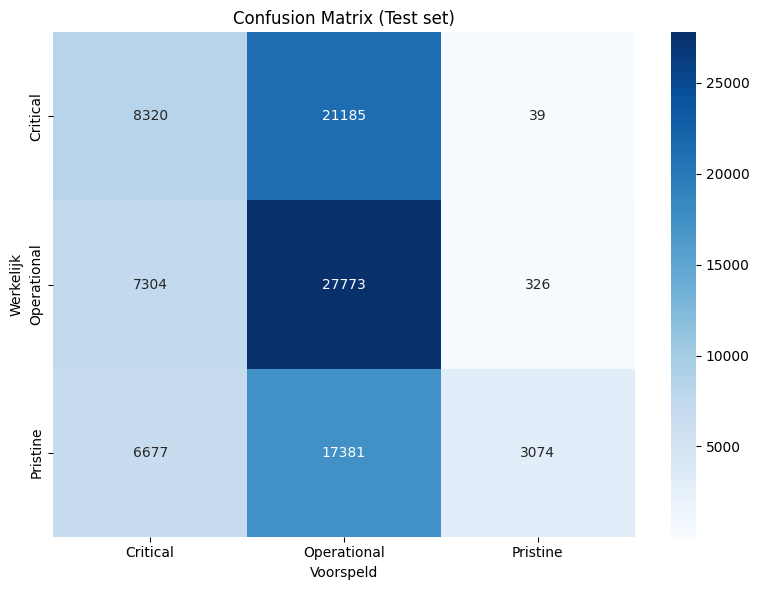

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print('Accuracy of train set:', accuracy_score(feature_train['Prediction'], target_train))
print('Accuracy of test set:', accuracy_score(feature_test['Prediction'], target_test))

print('\nClassification report (Test set):')
print(classification_report(target_test, feature_test['Prediction']))

labels = ["Critical", "Operational", "Pristine"]
cm = confusion_matrix(target_test, feature_test['Prediction'], labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix (Test set)")
plt.xlabel("Voorspeld")
plt.ylabel("Werkelijk")
plt.tight_layout()
plt.show()

**Conclusie**

Bovenaan zien we een *accuracy score*, een percentage dat simpelweg aangeeft in hoeveel procent van de gevallen we de staat van het schip goed hadden geraden. Dit meten we voor de 'Train-set' (om te kijken of het op de bekende data klopt) en, nog belangrijker, op de 'Test-set' (om te zien of onze theorie ook werkt voor *nieuwe* situaties).

Een algemeen percentage vertelt ons echter niet helemaal waar het fout gaat. Daarom kijken we ook naar een *confusion matrix* en een tabel met detailcijfers. Hiermee kunnen we precies zien voor welke specifieke groep ons model de mist in ging. Want let op: in de praktijk is het natuurlijk véél gevaarlijker om een enorm instabiel schip (`Critical`) onterecht door de keuring te laten komen als `Pristine`, dan andersom. Met deze inzichten kunnen we goed beoordelen of onze harde, handmatige regels wel betrouwbaar en veilig genoeg zijn voor de echte inspecties.

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*How well does your manual model identify 'Critical' or 'Pristine' ships? Did you meet the goals set in the Business Understanding?*

Ons handmatige model pikt de duidelijke 'Critical' en 'Pristine' schepen er best goed uit. We hebben simpele grenzen getrokken zoals Reactor_Power > 90, wat werkt voor extremen. Het grijze gebied, met name de normale 'Operational' schepen, blijft helaas lastig te scheiden.

We hebben de doelen uit Hoofdstuk 1 wel behaald: de data is netjes samengevoegd en opgeschoond. We hebben het onvoorspelbare inspecteurs vervangen door een transparant systeem met vaste regels. Een mooie eerste stap, al kan de nauwkeurigheid zeker beter.

**Key findings and limitations**
*What are the limitations of a manual, hard-rule-based system? Why might a machine Learning model be better in the next iteration?*

Het grootste nadeel van zelf if/else regels bedenken is dat ze heel zwart-wit zijn. Een grens van `90` is nogal random; waarom is een score van 89.9 'Pristine', en 90.1 opeens 'Critical'? Daarnaast is het voor ons lastig om complexe relaties tussen drie of meer variabelen tegelijk te overzien en te combineren in logische regels.

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset for the next iteration. 

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Damian van der Sluis | *Hoofdstuk 3 en 5* | Door hoofdstuk 3 te schrijven, heb ik gemerkt hoe belangrijk het is om bewust te kiezen hoe je missende data oplost, zoals de mediaan gebruiken voor Reactor Power in plaats van gewoon rijen weg te gooien. Ook zag ik bij de evaluatie heel goed de grenzen van ons if/else model in; het is praktisch ondoenlijk om het grote grijze tussengebied ('Operational') met simpele harde regels eerlijk te scheiden. |
| Saeed Alhasan | Hoofdstuk 4| Ik vond het leuk om de data inzichten zelf om te zetten in werkende if/else regels. Maar ik merkte wel dat het zelf bepalen van harde grenzen zoals bij de reactor power, best wel random voelt. Zeker bij twijfelgevallen kan je vaak mis zijn.|
| Achraf El Azzouzi | *Hoofdstuk 1 en 2* | In hoofdstuk 1 en 2 heb ik geleerd dat een sterke Business Understanding essentieel is om de juiste beslissingen te maken. Door data systematisch te verkennen met statistieken en visualisaties kon ik beter onderbouwen welke variabelen echt relevant zijn voor classificatieregels en hoe missende waarden verantwoord moeten worden behandeld. |